In [1]:
import numpy as np
from openmmtools.multistate import MultiStateReporter, ReplicaExchangeAnalyzer
from openmm import unit
kB = (unit.MOLAR_GAS_CONSTANT_R).in_units_of(unit.kilojoule / (unit.kelvin * unit.mole)).value_in_unit(unit.kilojoule / (unit.kelvin * unit.mole))
# print(kB)

from pymbar import timeseries

import matplotlib.pyplot as plt
plt.style.use('adjust_ys3')
import matplotlib.pyplot as plt
import numpy as np

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



In [2]:
output_file='output.nc'
reporter = MultiStateReporter(output_file, open_mode="r")


Could not locate checkpoint subfile. This is okay for analysis if the solvent trajectory is not needed, but not for production simulation!


In [3]:
analyzer = ReplicaExchangeAnalyzer(reporter)

# Read energies and states
replica_energies, _, _, replica_state_indices = analyzer.read_energies()

In [4]:
replica_state_indices.shape

(11, 400001)

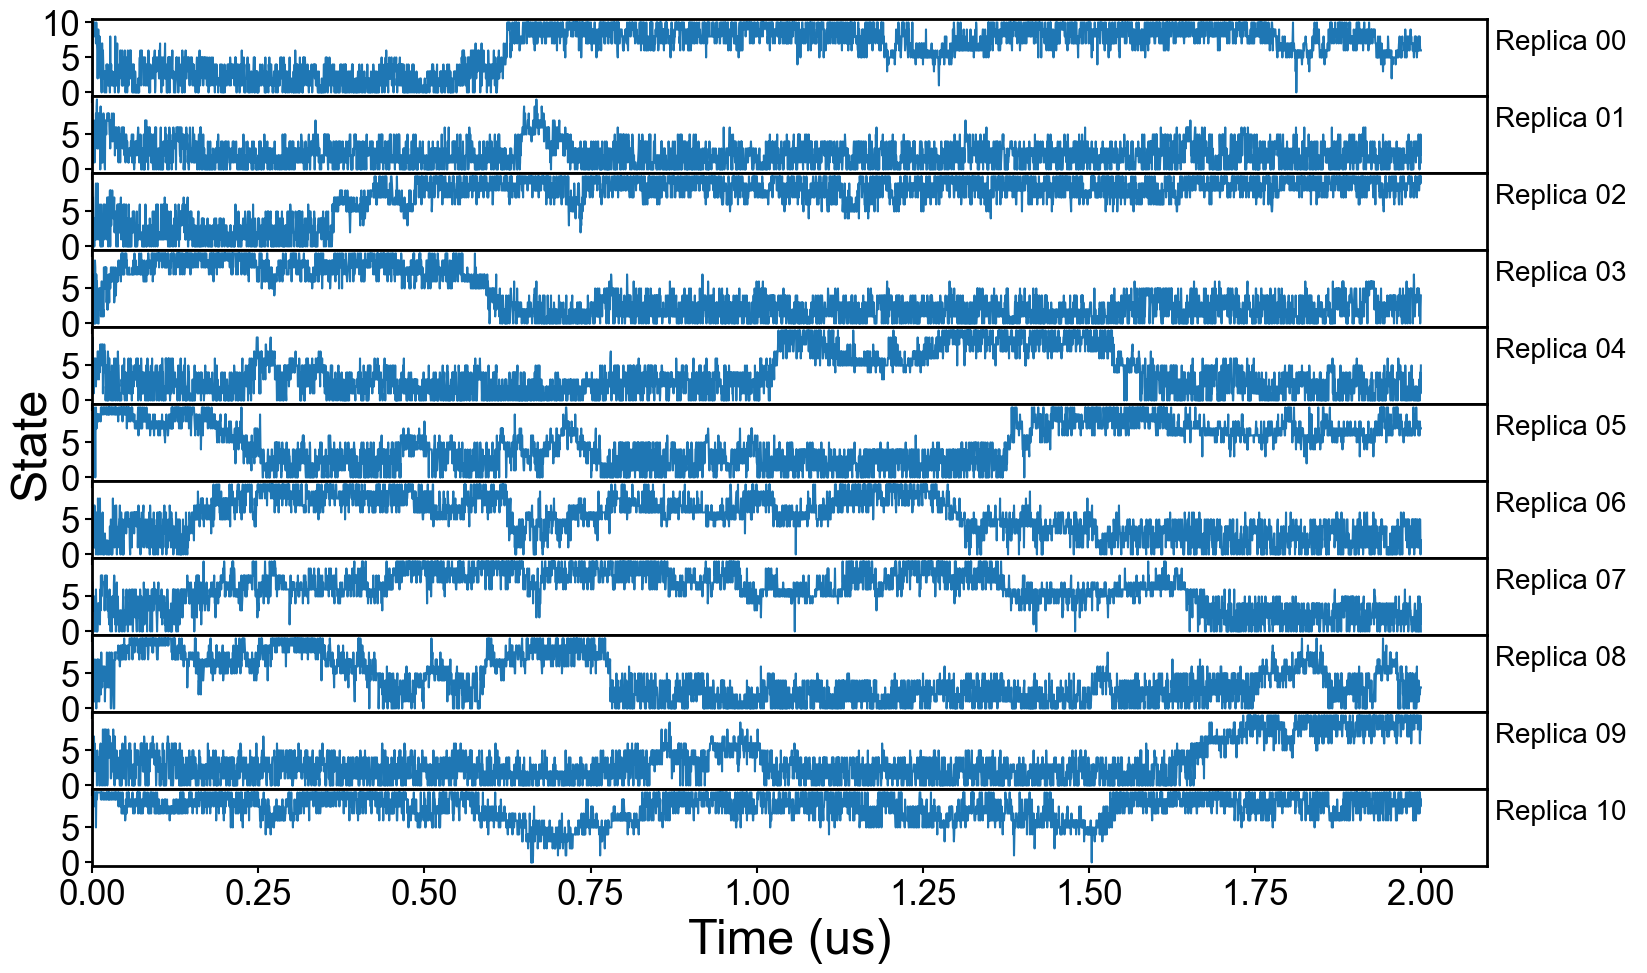

In [7]:


# Assuming replica_state_indices is a 2D array with shape (n_replica, n_timesteps)
n_replica = replica_state_indices.shape[0]  # Get number of states
skip = 100
# dt = 5/100000  # Time step in us
dt = 250 * 0.02 /1000000
x = np.arange(replica_state_indices.shape[1])


# Create figure with vertically stacked subplots
fig, axes = plt.subplots(n_replica, 1, figsize=(18, 1*n_replica), sharex=True)
fig.subplots_adjust(hspace=0)

labels = [f'Replica {i:02d}' for i in range(n_replica)]
for i, ax in enumerate(axes):
    ax.plot(x[::skip] * dt, replica_state_indices[i, ::skip], label=labels[i])
    ax.legend(loc="upper right", bbox_to_anchor=(1.11, 1.05), fontsize=20, handlelength=0)
    
    # ax.set_ylim(0,10)
    ax.set_yticks([0, 5])  # Set tick positions
    ax.tick_params(axis='y', labelsize=25)  # Set tick label fontsize
axes[0].set_yticks([0, 5, 10])  # Set tick positions
# ax.set_xlim(0, 1000)
    
# Only add xlabel to the bottom plot
    # ax.set_ylabel(f'State {i}')
ax.set_xlim(0, 2.1)
axes[5].set_ylabel('State')
# Only add xlabel to the bottom plot
axes[-1].set_xlabel('Time (us)')
plt.show()